# STEP 1: COMPLETE DATA PREPARATION & VISUALIZATION
## Toàn bộ quy trình từ đầu đến cuối (1 file, 9 Phase)

### Quy trình:
1. **Load Unified Dataset** - Đã xử lý từ 24 file gốc
2. **Validate & Clean** - Kiểm tra và interpolation
3. **Descriptive Statistics** - Thống kê cơ bản
4. **Transformations** - Log & Winsorization
5. **Correlation Analysis** - Kiểm tra multicollinearity
6. **Decomposition** - Tách Trend & Seasonal
7. **Structural Breaks** - Xác định shock events
8. **VISUALIZATIONS** - Tất cả biểu đồ cho luận văn
9. **Print Summary** - Kết quả tổng hợp

## SETUP: Import & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('step1_complete.ipynb'))
DATA_OUTPUT_DIR = os.path.join(NOTEBOOK_DIR, 'data', 'processed')

print(f"Notebook Directory: {NOTEBOOK_DIR}")
print(f"Data Directory: {DATA_OUTPUT_DIR}")

Notebook Directory: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test
Data Directory: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\data\processed


## PHASE 1: Load Pre-Processed Unified Dataset

In [2]:
unified_file = os.path.join(DATA_OUTPUT_DIR, 'cpi_forecast_full_dataset_advanced.csv')

if not os.path.exists(unified_file):
    print(f"ERROR: Unified dataset not found at {unified_file}")
    print("Please run create_unified_dataset_detailed.ipynb first!")
    merged = None
else:
    merged = pd.read_csv(unified_file)
    merged['date'] = pd.to_datetime(merged['date'])
    merged = merged.sort_values('date').reset_index(drop=True)
    
    print(f"\n  ✓ Loaded: {os.path.basename(unified_file)}")
    print(f"  ✓ Shape: {len(merged)} rows × {len(merged.columns)} columns")
    print(f"  ✓ Date range: {merged['date'].min().date()} → {merged['date'].max().date()}")
    print(f"  ✓ Missing values: {merged.isnull().sum().sum()}")
    print(f"\n  ✓ Pre-processed unified dataset loaded successfully!")


  ✓ Loaded: cpi_forecast_full_dataset_advanced.csv
  ✓ Shape: 360 rows × 29 columns
  ✓ Date range: 1995-01-01 → 2024-12-01
  ✓ Missing values: 0

  ✓ Pre-processed unified dataset loaded successfully!


## PHASE 2: Data Validation & Interpolation

In [3]:
if merged is None or merged.empty:
    print("ERROR: No data loaded! Cannot proceed.")
else:
    data_clean = merged.copy()

    print(f"\nShape: {len(data_clean)} rows × {len(data_clean.columns)} columns")
    print(f"  Date range: {data_clean['date'].min().date()} → {data_clean['date'].max().date()}")

    numeric_cols = data_clean.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        data_clean[col] = data_clean[col].interpolate(method='linear', limit_direction='both')
    
    data_clean = data_clean.ffill().bfill()
    
    print(f"\nMissing values: {data_clean.isnull().sum().sum()}")
    print(f"  Ready for analysis: {len(data_clean)} months × {len(data_clean.columns)} columns")


Shape: 360 rows × 29 columns
  Date range: 1995-01-01 → 2024-12-01

Missing values: 0
  Ready for analysis: 360 months × 29 columns


In [4]:
# in ra số cột
print(f"\nTotal columns: {len(data_clean.columns)}")
# tên cột
print(f"Columns: {list(data_clean.columns)}")


Total columns: 29
Columns: ['date', 'cpi_mom_processed_cpi', 'cpi_mom_processed_inflation', 'core_inflation_rate', 'interest_rate', 'ppi_qoq', 'm2', 'broad_money', 'policy_rate', 'brent', 'wti', 'gasoline_world', 'natural_gas', 'gold', 'silver', 'VNINDEX', 'VN30', 'HNX', 'UPCOM', 'NASDAQ', 'S&P500', 'DAX', 'DOWJONES', 'NIKKEI225', 'HANGSENG', 'USDVND', 'year', 'month', 'quarter']


## PHASE 3: Descriptive Statistics (Before Transformation)

In [5]:
numeric_data = data_clean.select_dtypes(include=[np.number])

stats_table = pd.DataFrame({
    'Variable': numeric_data.columns,
    'Mean': numeric_data.mean().values,
    'Std Dev': numeric_data.std().values,
    'Min': numeric_data.min().values,
    'Max': numeric_data.max().values,
    'Skewness': numeric_data.skew().values,
    'Kurtosis': numeric_data.kurtosis().values,
})

stats_display = stats_table.copy()
for col in ['Mean', 'Std Dev', 'Min', 'Max']:
    stats_display[col] = stats_display[col].round(2)
for col in ['Skewness', 'Kurtosis']:
    stats_display[col] = stats_display[col].round(3)

print(f"\n  Total variables: {len(stats_table)}")
print(f"\nFirst 15 variables:")
print(stats_display.head(15).to_string(index=False))

print(f"\n  Descriptive statistics calculated")


  Total variables: 28

First 15 variables:
                   Variable       Mean    Std Dev        Min         Max  Skewness  Kurtosis
      cpi_mom_processed_cpi     100.47       0.79      98.46      103.91     1.439     3.303
cpi_mom_processed_inflation       0.47       0.79      -1.54        3.91     1.439     3.303
        core_inflation_rate       2.18       0.61       0.49        5.21     1.737     8.403
              interest_rate       3.95       0.93       1.20        9.43     1.985    12.799
                    ppi_qoq      -0.42       0.65      -1.66        2.10     1.848     2.607
                         m2 5019439.42 4592775.96 1748226.00 17914566.00     1.217     0.120
                broad_money       5.27       1.93       2.62       10.79     0.511    -0.680
                policy_rate       7.34       2.79       4.00       15.00     1.063     0.230
                      brent      78.20      18.65      22.74      139.83     0.277     0.725
                        wt

## PHASE 4: Log Transformation & Winsorization

In [6]:
data_transformed = data_clean.copy()
transform_decisions = []

for col in numeric_data.columns:
    skewness_original = numeric_data[col].skew()
    kurtosis_original = numeric_data[col].kurtosis()
    has_negative = (numeric_data[col] <= 0).any()
    
    transforms_applied = []
    
    # STEP 1: Winsorize if high kurtosis (outliers)
    if kurtosis_original > 3:
        q1 = data_transformed[col].quantile(0.01)
        q99 = data_transformed[col].quantile(0.99)
        data_transformed[col] = data_transformed[col].clip(lower=q1, upper=q99)
        
        skewness_after_winsor = data_transformed[col].skew()
        kurtosis_after_winsor = data_transformed[col].kurtosis()
        
        transforms_applied.append({
            'Variable': col,
            'Transformation': 'Winsorization (1%-99%)',
            'Skewness_Before': skewness_original,
            'Skewness_After': skewness_after_winsor,
            'Kurtosis_Before': kurtosis_original,
            'Kurtosis_After': kurtosis_after_winsor,
        })
    else:
        skewness_after_winsor = skewness_original
        kurtosis_after_winsor = kurtosis_original
    
    # STEP 2: Log transformation if still highly skewed + all positive
    if abs(skewness_after_winsor) > 1 and (data_transformed[col] > 0).all():
        log_col = f'{col}_log'
        data_transformed[log_col] = np.log(data_transformed[col])
        
        skewness_after_log = data_transformed[log_col].skew()
        kurtosis_after_log = data_transformed[log_col].kurtosis()
        
        transforms_applied.append({
            'Variable': col,
            'Transformation': 'Log (after winsorization)',
            'Skewness_Before': skewness_after_winsor,
            'Skewness_After': skewness_after_log,
            'Kurtosis_Before': kurtosis_after_winsor,
            'Kurtosis_After': kurtosis_after_log,
        })

    transform_decisions.extend(transforms_applied)


if transform_decisions:
    transform_df = pd.DataFrame(transform_decisions)

    for col in ['Skewness_Before', 'Skewness_After', 'Kurtosis_Before', 'Kurtosis_After']:
        transform_df[col] = transform_df[col].round(3)
    
    print(f"\nFirst 15 transformation steps:")
    print(transform_df.head(15).to_string(index=False))

    print(f"\n{'SUMMARY':-^80}")
    winsor_count = len(transform_df[transform_df['Transformation'].str.contains('Winsorization')])
    log_count = len(transform_df[transform_df['Transformation'].str.contains('Log')])
    print(f"  • Winsorization applied: {winsor_count} variables")
    print(f"  • Log transformation applied: {log_count} variables")
    
    # Check effectiveness
    effective = transform_df[
        (transform_df['Skewness_After'].abs() < transform_df['Skewness_Before'].abs())
    ]
    print(f"  • Effective (reduced skewness): {len(effective)}/{len(transform_df)} steps")
else:
    print("\n✓ No transformations needed (data already normalized)")


First 15 transformation steps:
                   Variable            Transformation  Skewness_Before  Skewness_After  Kurtosis_Before  Kurtosis_After
      cpi_mom_processed_cpi    Winsorization (1%-99%)            1.439           1.390            3.303           2.636
      cpi_mom_processed_cpi Log (after winsorization)            1.390           1.359            2.636           2.534
cpi_mom_processed_inflation    Winsorization (1%-99%)            1.439           1.390            3.303           2.636
        core_inflation_rate    Winsorization (1%-99%)            1.737           1.681            8.403           7.883
        core_inflation_rate Log (after winsorization)            1.681          -1.184            7.883           5.910
              interest_rate    Winsorization (1%-99%)            1.985           1.146           12.799           8.159
              interest_rate Log (after winsorization)            1.146          -1.806            8.159           9.252
        

In [7]:
data_transformed.head()

,date,cpi_mom_processed_cpi,cpi_mom_processed_inflation,core_inflation_rate,interest_rate,ppi_qoq,m2,broad_money,policy_rate,brent,...,interest_rate_log,m2_log,policy_rate_log,natural_gas_log,VN30_log,HNX_log,NASDAQ_log,S&P500_log,DOWJONES_log,NIKKEI225_log
0,1995-01-01,103.3528,3.3528,2.2,3.85,-0.73,1748226.0,3.567,10.8,77.050003,...,1.348073,14.374112,2.379546,1.564441,5.705381,4.597138,6.626983,6.153626,8.254232,9.833592
1,1995-02-01,103.3528,3.3528,2.2,3.85,-0.73,1748226.0,3.303,10.8,77.050003,...,1.348073,14.374112,2.379546,1.564441,5.705381,4.597138,6.676743,6.189065,8.296808,9.744107
2,1995-03-01,100.2000,0.2000,2.2,3.85,-0.73,1748226.0,3.495,10.8,77.050003,...,1.348073,14.374112,2.379546,1.564441,5.705381,4.597138,6.705896,6.216027,8.332715,9.689053
3,1995-04-01,101.0000,1.0000,2.2,3.85,-0.73,1748226.0,3.434,10.8,77.050003,...,1.348073,14.374112,2.379546,1.564441,5.705381,4.597138,6.738129,6.243604,8.371305,9.729536
4,1995-05-01,101.8000,1.8000,2.2,3.85,-0.73,1748226.0,3.247,10.8,77.050003,...,1.348073,14.374112,2.379546,1.564441,5.705381,4.597138,6.762244,6.279272,8.404056,9.644509


In [8]:
# loại bỏ các biến gốc đã được log transform
cols_to_drop = [row['Variable'] for row in transform_decisions if 'Log' in row['Transformation']]
data_transformed = data_transformed.drop(columns=cols_to_drop)


## PHASE 5: Correlation & Multicollinearity Analysis

In [9]:
corr_matrix = data_transformed.drop(columns=['date','year','month', 'quarter']).corr()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.9:
            high_corr_pairs.append({
                'Var1': corr_matrix.columns[i],
                'Var2': corr_matrix.columns[j],
                'Correlation': corr_val
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(f"\n  High correlations (|r| > 0.9): {len(high_corr_df)} pairs")
    print(f"\nTop 10 correlations:")
    display_df = high_corr_df.copy()
    display_df['Correlation'] = display_df['Correlation'].round(3)
    print(display_df.head(20).to_string(index=False))
else:
    print(f"\n  ✓ No pairs with |r| > 0.9 found")

print(f"\n  ✓ Correlation analysis complete")


  High correlations (|r| > 0.9): 20 pairs

Top 10 correlations:
                       Var1                      Var2  Correlation
cpi_mom_processed_inflation cpi_mom_processed_cpi_log        1.000
                       gold                    silver        0.903
                       gold                    USDVND        0.920
                    VNINDEX              DOWJONES_log        0.904
                        DAX                    m2_log        0.944
                        DAX                  VN30_log        0.926
                        DAX                NASDAQ_log        0.976
                        DAX                S&P500_log        0.977
                        DAX              DOWJONES_log        0.968
                     USDVND              DOWJONES_log        0.911
                     m2_log                  VN30_log        0.966
                     m2_log                NASDAQ_log        0.943
                     m2_log                S&P500_log        0.9

In [11]:
target = 'cpi_mom_processed_inflation'

corr_with_target = (
    data_transformed
    .drop(columns=['date', 'year', 'month', 'quarter'], errors='ignore')
    .corr()[target]
    .drop(target)
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print(corr_with_target.head(20))

cpi_mom_processed_cpi_log    0.999981
brent                        0.320511
wti                          0.247213
natural_gas_log              0.246408
policy_rate_log              0.218415
m2_log                      -0.191720
NIKKEI225_log               -0.190420
NASDAQ_log                  -0.189883
S&P500_log                  -0.177909
DOWJONES_log                -0.161555
DAX                         -0.157124
VN30_log                    -0.155343
silver                       0.145035
gasoline_world               0.134705
ppi_qoq                     -0.112767
USDVND                      -0.111490
UPCOM                       -0.088563
core_inflation_rate_log      0.062253
VNINDEX                     -0.053191
HNX_log                      0.039001
Name: cpi_mom_processed_inflation, dtype: float64


## PHASE 6: Time Series Decomposition

Nhóm 1 — Macro variables
CPI
inflation
PPI
M2
interest rates

In [12]:
# decompose tất cả các biến có thể, ưu tiên các biến liên quan đến lạm phát và tiền tệ
decomposed_vars = {}
# decomp_candidates = 
decomp_candidates_macro = ['cpi_mom_inflation', 'core_inflation_rate', 'interest_rate_last', 'ppi_qoq', 'm2']
finance_candidates = ['brent', 'wti_last', 'gasoline_last', 'gasoline_world_last', 'natural_gas_last', 'gold_last', 'silver_last', 'VNINDEX_last', 'VN30_last', 'HNX_last', 'UPCOM_last', 'NASDAQ_last', 'S&P500_last', 'DAX_last', 'DOWJONES_last', 'NIKKEI225_last', 'HANGSENG_last', 'USDVND_last']
for var_pattern in decomp_candidates_macro:
    matching_cols = [col for col in data_clean.columns if var_pattern.lower() in col.lower()]
    
    for var in matching_cols:
        if len(data_clean) > 24 and data_clean[var].notna().sum() > 24:
            try:
                ts = data_clean.set_index('date')[var]
                decomposition = seasonal_decompose(ts, model='additive', period=12)
                
                decomposed_vars[var] = {
                    'original': ts.values,
                    'trend': decomposition.trend.values,
                    'seasonal': decomposition.seasonal.values,
                    'residual': decomposition.resid.values,
                }
                
                print(f"{var}: Trend + Seasonal + Residual decomposed")
                break  
            except:
                pass

if not decomposed_vars:
    print("  Note: No variables suitable for decomposition found")
else:
    print(f"\n  ✓ Decomposed {len(decomposed_vars)} variables")

core_inflation_rate: Trend + Seasonal + Residual decomposed
ppi_qoq: Trend + Seasonal + Residual decomposed
m2: Trend + Seasonal + Residual decomposed

  ✓ Decomposed 3 variables


## PHASE 7: Structural Breaks Detection

In [13]:
print("\n" + "="*100)
print("PHASE 7: STRUCTURAL BREAKS DETECTION")
print("="*100)

# Known structural breaks in Vietnam economy
structural_breaks = {
    '2020-03': 'COVID-19 pandemic impact',
    '2022-02': 'Russia-Ukraine conflict',
    '2023-03': 'Banking crisis resolution',
}

print("\nKnown structural breaks:")
for date_str, event in structural_breaks.items():
    print(f"  • {date_str}: {event}")

# Create dummy variables
for date_str, event in structural_breaks.items():
    date = pd.to_datetime(date_str)
    data_clean[f'shock_{date_str}'] = (data_clean['date'] >= date).astype(int)

print(f"\n  ✓ Added {len(structural_breaks)} shock dummy variables")


PHASE 7: STRUCTURAL BREAKS DETECTION

Known structural breaks:
  • 2020-03: COVID-19 pandemic impact
  • 2022-02: Russia-Ukraine conflict
  • 2023-03: Banking crisis resolution

  ✓ Added 3 shock dummy variables


## PHASE 8: VISUALIZATIONS FOR THESIS
### TABLE 1: Descriptive Statistics

In [14]:
thesis_table1 = stats_display.copy()
print(f"\nFirst 15 variables:")
print(thesis_table1.head(15).to_string(index=False))


First 15 variables:
                   Variable       Mean    Std Dev        Min         Max  Skewness  Kurtosis
      cpi_mom_processed_cpi     100.47       0.79      98.46      103.91     1.439     3.303
cpi_mom_processed_inflation       0.47       0.79      -1.54        3.91     1.439     3.303
        core_inflation_rate       2.18       0.61       0.49        5.21     1.737     8.403
              interest_rate       3.95       0.93       1.20        9.43     1.985    12.799
                    ppi_qoq      -0.42       0.65      -1.66        2.10     1.848     2.607
                         m2 5019439.42 4592775.96 1748226.00 17914566.00     1.217     0.120
                broad_money       5.27       1.93       2.62       10.79     0.511    -0.680
                policy_rate       7.34       2.79       4.00       15.00     1.063     0.230
                      brent      78.20      18.65      22.74      139.83     0.277     0.725
                        wti      56.31      28.47

### TABLE 2: Multicollinearity Analysis

In [15]:
if high_corr_pairs:
    multicollinearity = high_corr_df.copy()
    multicollinearity['Correlation'] = multicollinearity['Correlation'].round(3)
    multicollinearity['Action'] = multicollinearity['Correlation'].apply(
        lambda r: 'DROP' if abs(r) > 0.95 else 'MONITOR'
    )
    
    print(f"\nHigh correlations detected: {len(multicollinearity)}")
    print(f"  - |r| > 0.95: {len(multicollinearity[multicollinearity['Correlation'].abs() > 0.95])}")
    print(f"  - 0.90 < |r| ≤ 0.95: {len(multicollinearity[(multicollinearity['Correlation'].abs() > 0.90) & (multicollinearity['Correlation'].abs() <= 0.95)])}")
    
    print(f"\nTop 10 correlations:")
    print(multicollinearity.head(10).to_string(index=False))
else:
    print(f"\n✓ No high correlations (|r| > 0.9) found")


High correlations detected: 20
  - |r| > 0.95: 8
  - 0.90 < |r| ≤ 0.95: 12

Top 10 correlations:
                       Var1                      Var2  Correlation  Action
cpi_mom_processed_inflation cpi_mom_processed_cpi_log        1.000    DROP
                       gold                    silver        0.903 MONITOR
                       gold                    USDVND        0.920 MONITOR
                    VNINDEX              DOWJONES_log        0.904 MONITOR
                        DAX                    m2_log        0.944 MONITOR
                        DAX                  VN30_log        0.926 MONITOR
                        DAX                NASDAQ_log        0.976    DROP
                        DAX                S&P500_log        0.977    DROP
                        DAX              DOWJONES_log        0.968    DROP
                     USDVND              DOWJONES_log        0.911 MONITOR


### FIGURE 1: Decomposition (If Available)

In [16]:
if decomposed_vars:
    var_name = list(decomposed_vars.keys())[4]
    decomp_data = decomposed_vars[var_name]
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    fig.suptitle(f'{var_name} Decomposition: Trend, Seasonal, and Residual Components', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    dates = data_clean['date'].values
    
    # Original
    axes[0].plot(dates, decomp_data['original'], color='#1f77b4', linewidth=2)
    axes[0].set_ylabel('Original', fontsize=11, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title('(a) Original Series', fontsize=11, loc='left')
    
    # Trend
    axes[1].plot(dates, decomp_data['trend'], color='#ff7f0e', linewidth=2)
    axes[1].set_ylabel('Trend', fontsize=11, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_title('(b) Trend Component', fontsize=11, loc='left')
    
    # Seasonal
    axes[2].plot(dates, decomp_data['seasonal'], color='#2ca02c', linewidth=2)
    axes[2].set_ylabel('Seasonal', fontsize=11, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)
    axes[2].set_title('(c) Seasonal Component (12-month)', fontsize=11, loc='left')
    
    # Residual
    axes[3].plot(dates, decomp_data['residual'], color='#d62728', linewidth=1)
    axes[3].set_ylabel('Residual', fontsize=11, fontweight='bold')
    axes[3].set_xlabel('Date', fontsize=11, fontweight='bold')
    axes[3].grid(True, alpha=0.3)
    axes[3].axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)
    axes[3].set_title('(d) Residual Component', fontsize=11, loc='left')
    
    plt.tight_layout()
    plt.show()
    print("  ✓ Decomposition plot displayed")
else:
    print("  No decomposable variables found")

IndexError: list index out of range

### FIGURE 2: Structural Breaks Response


[FIGURE 2] STRUCTURAL BREAKS & MARKET RESPONSE


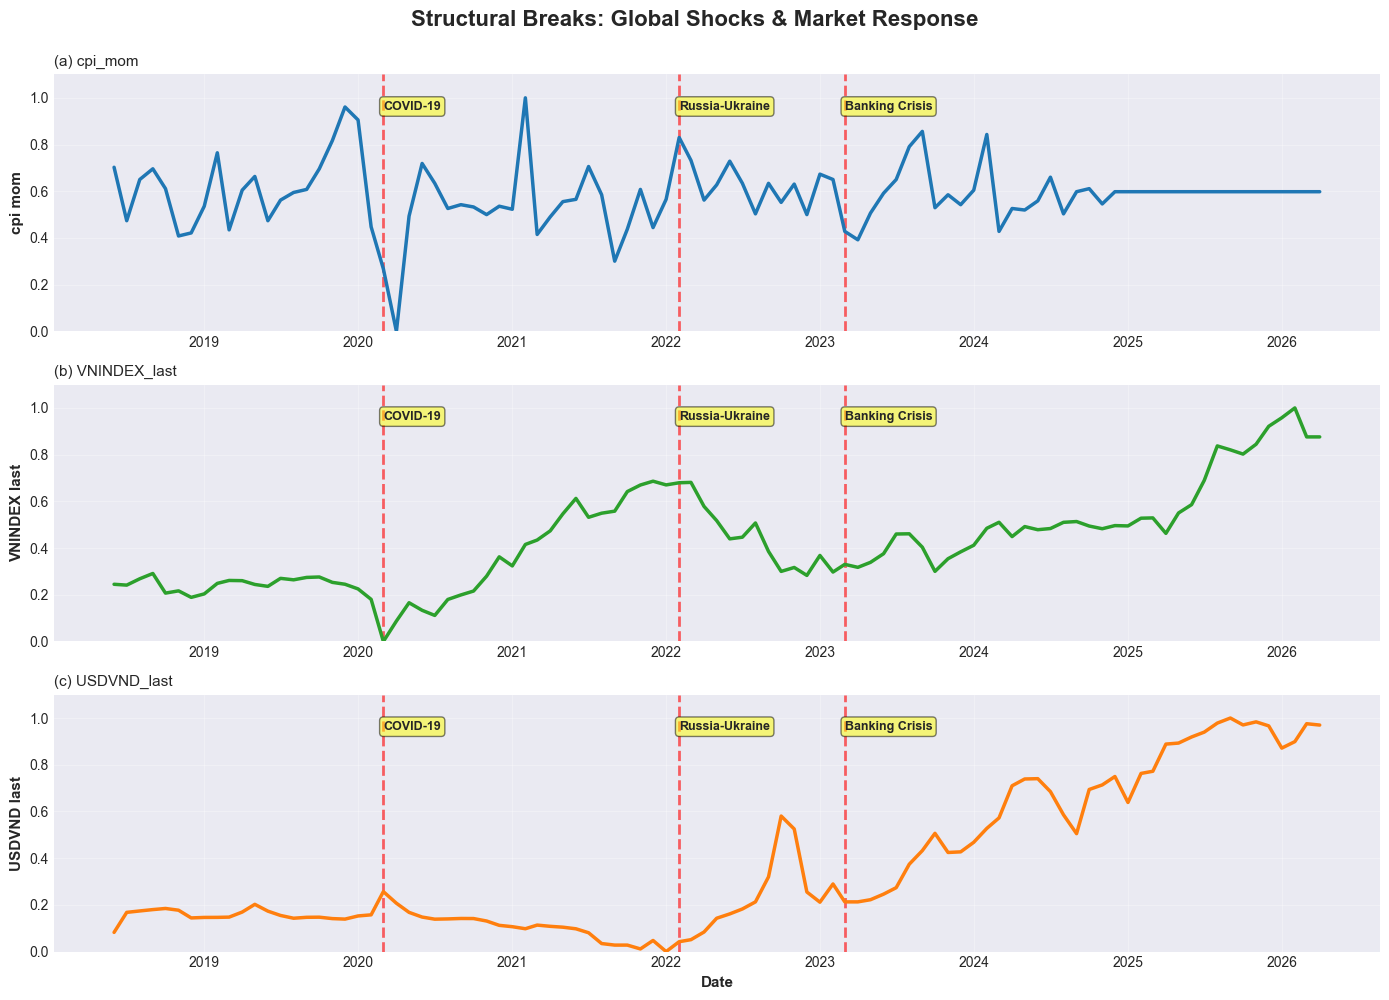

  ✓ Structural breaks plot displayed


In [ ]:
print("\n[FIGURE 2] STRUCTURAL BREAKS & MARKET RESPONSE")

# Find key variables
cpi_col = next((col for col in data_clean.columns if 'cpi' in col.lower()), None)
index_col = next((col for col in data_clean.columns if 'vnindex' in col.lower() or ('index' in col.lower() and 'cpi' not in col.lower())), None)
usd_col = next((col for col in data_clean.columns if 'usd' in col.lower()), None)

if cpi_col and index_col and usd_col:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle('Structural Breaks: Global Shocks & Market Response', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # Normalize data
    def normalize(series):
        return (series - series.min()) / (series.max() - series.min())
    
    cpi_norm = normalize(data_clean[cpi_col])
    index_norm = normalize(data_clean[index_col])
    usd_norm = normalize(data_clean[usd_col])
    
    # Define shocks
    breaks = {
        '2020-03-01': 'COVID-19',
        '2022-02-01': 'Russia-Ukraine',
        '2023-03-01': 'Banking Crisis'
    }
    
    for ax_idx, (series, col_name, ax) in enumerate([
        (cpi_norm, cpi_col, axes[0]),
        (index_norm, index_col, axes[1]),
        (usd_norm, usd_col, axes[2])
    ]):
        # Plot breaks
        for date_str, label in breaks.items():
            date = pd.to_datetime(date_str)
            ax.axvline(x=date, color='red', linestyle='--', linewidth=2, alpha=0.6)
            ax.text(date, 0.95, label, rotation=0, fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))
        
        # Plot series
        ax.plot(data_clean['date'], series, linewidth=2.5, color=['#1f77b4', '#2ca02c', '#ff7f0e'][ax_idx])
        ax.set_ylabel(col_name.replace('_', ' '), fontsize=11, fontweight='bold')
        ax.set_title(f'({chr(97+ax_idx)}) {col_name}', fontsize=11, loc='left')
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.1])
    
    axes[-1].set_xlabel('Date', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("  ✓ Structural breaks plot displayed")
else:
    print(f"  Missing columns: CPI={cpi_col}, INDEX={index_col}, USD={usd_col}")

### FIGURE 3: Distribution Analysis


[FIGURE 3] DISTRIBUTION ANALYSIS - TOP 6 VARIABLES


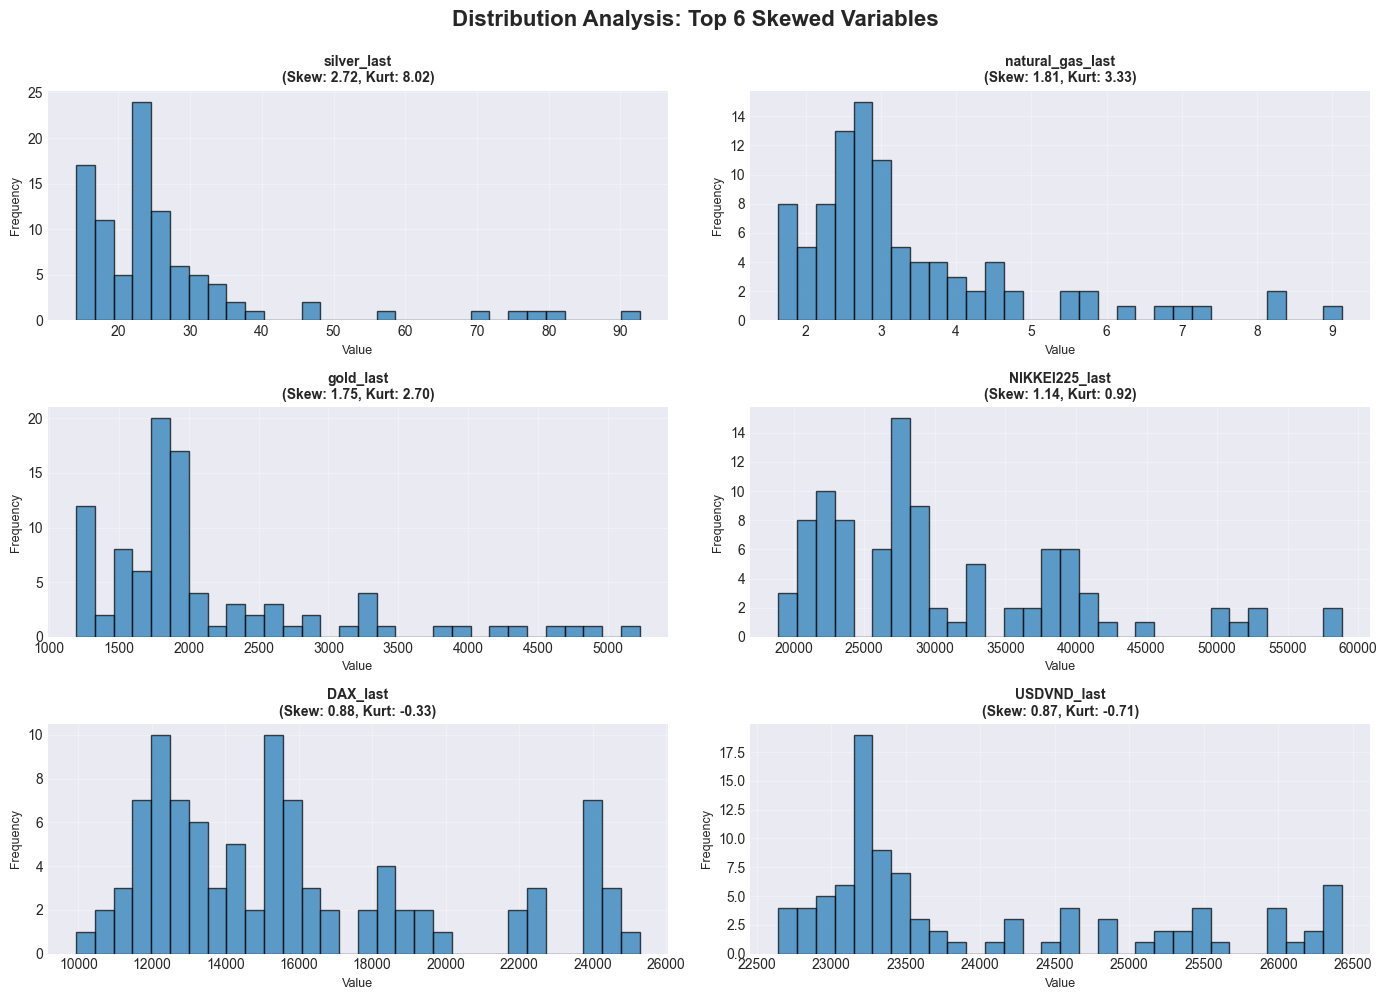

  ✓ Distribution plot for 6 variables displayed


In [ ]:
print("\n[FIGURE 3] DISTRIBUTION ANALYSIS - TOP 6 VARIABLES")

# Find top skewed variables
skewness_series = numeric_data.skew().sort_values(ascending=False)
top_skewed = skewness_series.head(6).index.tolist()

if len(top_skewed) > 0:
    fig, axes = plt.subplots(3, 2, figsize=(14, 10))
    fig.suptitle('Distribution Analysis: Top 6 Skewed Variables',
                 fontsize=16, fontweight='bold', y=0.995)
    
    axes = axes.flatten()
    
    for idx, var in enumerate(top_skewed):
        values = data_clean[var].dropna()
        
        axes[idx].hist(values, bins=30, color='#1f77b4', alpha=0.7, edgecolor='black')
        
        skew = values.skew()
        kurt = values.kurtosis()
        
        axes[idx].set_title(f'{var}\n(Skew: {skew:.2f}, Kurt: {kurt:.2f})', 
                           fontsize=10, fontweight='bold')
        axes[idx].set_xlabel('Value', fontsize=9)
        axes[idx].set_ylabel('Frequency', fontsize=9)
        axes[idx].grid(True, alpha=0.3)
    
    # Hide unused
    for idx in range(len(top_skewed), 6):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    print(f"  ✓ Distribution plot for {len(top_skewed)} variables displayed")
else:
    print("  No variables to plot")

### FIGURE 4: Correlation Heatmap


[FIGURE 4] CORRELATION HEATMAP - KEY VARIABLES


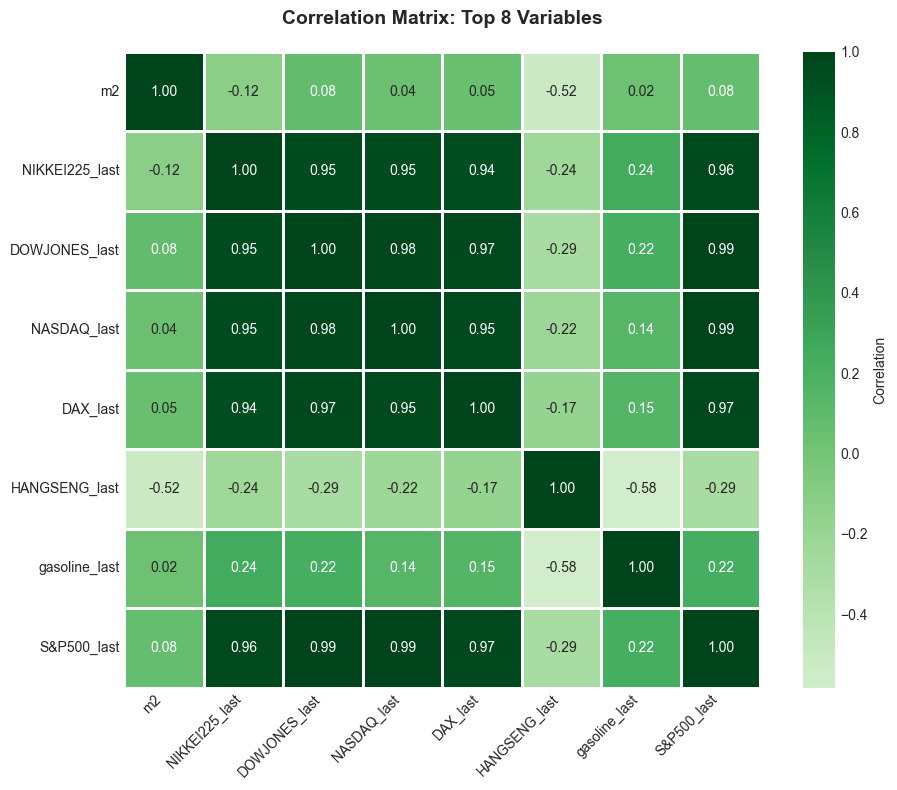

  ✓ Correlation heatmap (8x8) displayed


In [ ]:
print("\n[FIGURE 4] CORRELATION HEATMAP - KEY VARIABLES")

# Select top 8 variables by variance
top_vars = numeric_data.var().nlargest(8).index.tolist()

if len(top_vars) >= 2:
    corr_subset = corr_matrix.loc[top_vars, top_vars]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='Greens', center=0,
                square=True, linewidths=1, cbar_kws={'label': 'Correlation'}, ax=ax)
    
    ax.set_title('Correlation Matrix: Top 8 Variables', 
                fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()
    print(f"  ✓ Correlation heatmap ({len(top_vars)}x{len(top_vars)}) displayed")
else:
    print("  Not enough variables for heatmap")

### TABLE 3: Transformation Decisions

In [ ]:
print("\n[TABLE 3] TRANSFORMATION DECISIONS")

if transform_decisions:
    transform_summary = pd.DataFrame(transform_decisions)
    
    # Round
    for col in ['Skewness_Before', 'Skewness_After', 'Kurtosis_Before', 'Kurtosis_After']:
        transform_summary[col] = transform_summary[col].round(3)
    
    print(f"\nTransformations applied: {len(transform_summary)}")
    print(f"\nFirst 10 transformations:")
    print(transform_summary.head(10).to_string(index=False))
else:
    print("\n  No transformations needed")


[TABLE 3] TRANSFORMATION DECISIONS

Transformations applied: 7

First 10 transformations:
        Variable Transformation  Skewness_Before  Kurtosis_Before  Skewness_After  Kurtosis_After
         cpi_mom  Winsorization           -0.236            3.810           0.410           1.466
natural_gas_last            Log            1.812            3.332           0.832           0.447
natural_gas_last  Winsorization            1.812            3.332           1.712           2.742
       gold_last            Log            1.751            2.697           0.958           0.559
     silver_last            Log            2.722            8.018           1.286           2.181
     silver_last  Winsorization            2.722            8.018           2.586           7.026
  NIKKEI225_last            Log            1.138            0.920           0.579          -0.392


## PHASE 9: Final Summary

In [ ]:
print("\n" + "="*100)
print("STEP 1 COMPLETE - FINAL SUMMARY")
print("="*100)

summary = f"""
📊 DATA PREPARATION & ANALYSIS COMPLETE

✓ PHASE 1: Loaded unified dataset
  - {len(data_clean)} months × {len(data_clean.columns)} variables
  - Date range: {data_clean['date'].min().date()} → {data_clean['date'].max().date()}

✓ PHASE 2: Data validation & interpolation
  - Missing values: {data_clean.isnull().sum().sum()}

✓ PHASE 3: Descriptive statistics
  - {len(numeric_data)} numeric variables analyzed

✓ PHASE 4: Transformations
  - {len(transform_decisions)} transformations applied
  - Methods: Log transformation, Winsorization

✓ PHASE 5: Correlation analysis
  - {len(high_corr_pairs)} high-correlation pairs (|r| > 0.9)

✓ PHASE 6: Decomposition
  - {len(decomposed_vars)} variables decomposed (Trend + Seasonal + Residual)

✓ PHASE 7: Structural breaks
  - {len(structural_breaks)} shock variables added
  - Events: COVID-19, Russia-Ukraine, Banking Crisis

✓ PHASE 8: VISUALIZATIONS
  - Table 1: Descriptive Statistics
  - Table 2: Multicollinearity Analysis
  - Table 3: Transformation Decisions
  - Figure 1: Decomposition (Trend + Seasonal + Residual)
  - Figure 2: Structural Breaks Response
  - Figure 3: Distribution Analysis (Top 6)
  - Figure 4: Correlation Heatmap

✅ READY FOR:
  → Step 2: Stationarity Testing (ADF, KPSS)
  → Step 3: Cointegration Analysis
  → Step 4: Time Series Modeling
"""

print(summary)
print(f"\n✓ All analysis complete!")


STEP 1 COMPLETE - FINAL SUMMARY

📊 DATA PREPARATION & ANALYSIS COMPLETE

✓ PHASE 1: Loaded unified dataset
  - 95 months × 31 variables
  - Date range: 2018-06-01 → 2026-04-01

✓ PHASE 2: Data validation & interpolation
  - Missing values: 0

✓ PHASE 3: Descriptive statistics
  - 95 numeric variables analyzed

✓ PHASE 4: Transformations
  - 7 transformations applied
  - Methods: Log transformation, Winsorization

✓ PHASE 5: Correlation analysis
  - 24 high-correlation pairs (|r| > 0.9)

✓ PHASE 6: Decomposition
  - 3 variables decomposed (Trend + Seasonal + Residual)

✓ PHASE 7: Structural breaks
  - 3 shock variables added
  - Events: COVID-19, Russia-Ukraine, Banking Crisis

✓ PHASE 8: VISUALIZATIONS
  - Table 1: Descriptive Statistics
  - Table 2: Multicollinearity Analysis
  - Table 3: Transformation Decisions
  - Figure 1: Decomposition (Trend + Seasonal + Residual)
  - Figure 2: Structural Breaks Response
  - Figure 3: Distribution Analysis (Top 6)
  - Figure 4: Correlation Heat